In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/world_happiness_2026 (3).csv")
df

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481
...,...,...,...,...,...,...,...,...,...,...
125,126,Central African Republic,Sub-Saharan Africa,3.441,0.171,0.691,0.341,0.261,0.131,0.011
126,127,South Sudan,Sub-Saharan Africa,3.421,0.361,0.691,0.341,0.221,0.171,0.011
127,128,Sierra Leone,Sub-Saharan Africa,3.401,0.351,0.741,0.371,0.311,0.201,0.021
128,129,Congo DR,Sub-Saharan Africa,2.761,0.191,0.601,0.311,0.201,0.141,0.011


In [ ]:
df.columns

Index(['rank', 'country', 'region', 'score', 'gdp_per_capita',
       'social_support', 'healthy_life_expectancy', 'freedom', 'generosity',
       'corruption'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     130 non-null    int64  
 1   country                  130 non-null    object 
 2   region                   130 non-null    object 
 3   score                    130 non-null    float64
 4   gdp_per_capita           130 non-null    float64
 5   social_support           130 non-null    float64
 6   healthy_life_expectancy  130 non-null    float64
 7   freedom                  130 non-null    float64
 8   generosity               130 non-null    float64
 9   corruption               130 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 10.3+ KB


In [ ]:
df.describe()

,rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,65.500000,5.454185,1.135446,1.176754,0.732015,0.483162,0.164823,0.178231
std,37.671829,1.255681,0.559534,0.259117,0.190572,0.118050,0.055821,0.134135
min,1.000000,1.446000,0.171000,0.341000,0.311000,0.071000,0.061000,0.011000
25%,33.250000,4.136000,0.671000,0.941000,0.563500,0.393500,0.131000,0.071000
50%,65.500000,5.581000,1.121000,1.241000,0.791000,0.491000,0.161000,0.141000
75%,97.750000,6.396000,1.631000,1.378500,0.891000,0.571000,0.201000,0.261000
max,130.000000,7.764000,2.121000,1.611000,0.961000,0.671000,0.301000,0.512000


In [ ]:
df.dtypes

,0
rank,int64
country,object
region,object
score,float64
gdp_per_capita,float64
social_support,float64
healthy_life_expectancy,float64
freedom,float64
generosity,float64
corruption,float64


In [ ]:
df.shape

(130, 10)

In [ ]:
df.size

1300

The dataset shows us different level of happiness in different countires based on their GDP Per capita , social support , health life expectancy ,corruption

In [ ]:
df.isnull().sum()

,0
rank,0
country,0
region,0
score,0
gdp_per_capita,0
social_support,0
healthy_life_expectancy,0
freedom,0
generosity,0
corruption,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()

,rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
rank,1.000000,-0.978587,-0.898676,-0.954318,-0.889165,-0.912114,-0.227896,-0.900299
score,-0.978587,1.000000,0.879284,0.976465,0.900567,0.932961,0.236826,0.874750
gdp_per_capita,-0.898676,0.879284,1.000000,0.924592,0.920075,0.837684,0.053799,0.893436
social_support,-0.954318,0.976465,0.924592,1.000000,0.952903,0.919010,0.175739,0.864591
healthy_life_expectancy,-0.889165,0.900567,0.920075,0.952903,1.000000,0.833271,0.035427,0.817594
freedom,-0.912114,0.932961,0.837684,0.919010,0.833271,1.000000,0.426645,0.881999
generosity,-0.227896,0.236826,0.053799,0.175739,0.035427,0.426645,1.000000,0.330154
corruption,-0.900299,0.874750,0.893436,0.864591,0.817594,0.881999,0.330154,1.000000


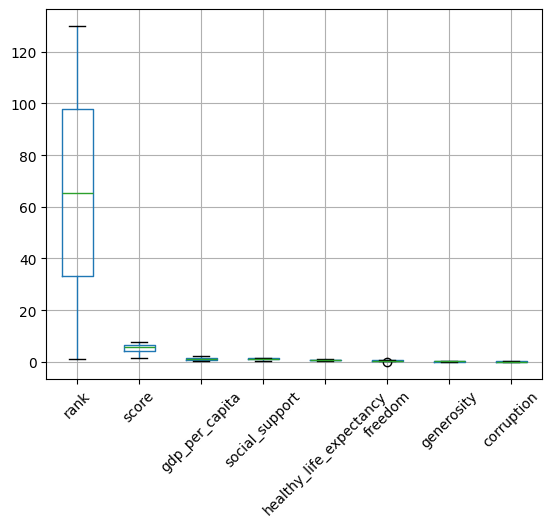

In [ ]:
import matplotlib.pyplot as plt
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outliers.sum()

,0
rank,0
score,0
gdp_per_capita,0
social_support,0
healthy_life_expectancy,0
freedom,1
generosity,0
corruption,0


<Axes: >

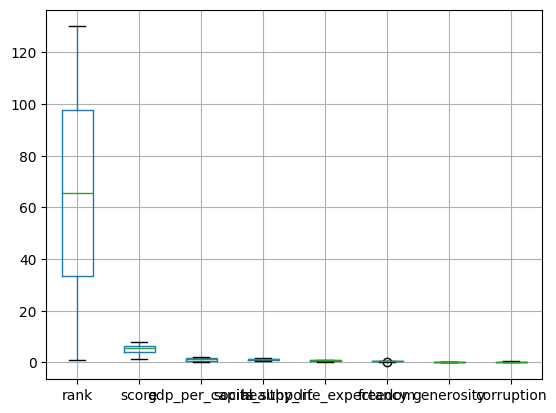

In [ ]:
df.select_dtypes(include=['number']).boxplot()

The dataset contains both numeric and categorical variables (including country names and score-related features). During exploratory data analysis, no missing values were found, and the dataset was confirmed to be clean. Numeric columns were analyzed using descriptive statistics, showing a normal range of values without significant outliers based on boxplot and IQR methods. Correlation analysis was performed on numeric features only, as categorical variables were excluded from mathematical operations. Overall, the dataset is well-structured, consistent, and suitable for further analysis or machine learning tasks

